In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.datasets import load_diabetes
diabetes=load_diabetes()

In [3]:
diabetes['DESCR']

'.. _diabetes_dataset:\n\nDiabetes dataset\n----------------\n\nTen baseline variables, age, sex, body mass index, average blood\npressure, and six blood serum measurements were obtained for each of n =\n442 diabetes patients, as well as the response of interest, a\nquantitative measure of disease progression one year after baseline.\n\n**Data Set Characteristics:**\n\n:Number of Instances: 442\n\n:Number of Attributes: First 10 columns are numeric predictive values\n\n:Target: Column 11 is a quantitative measure of disease progression one year after baseline\n\n:Attribute Information:\n    - age     age in years\n    - sex\n    - bmi     body mass index\n    - bp      average blood pressure\n    - s1      tc, total serum cholesterol\n    - s2      ldl, low-density lipoproteins\n    - s3      hdl, high-density lipoproteins\n    - s4      tch, total cholesterol / HDL\n    - s5      ltg, possibly log of serum triglycerides level\n    - s6      glu, blood sugar level\n\nNote: Each of thes

In [4]:
#independent and dependent features
y=diabetes['target']
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [5]:
X=pd.DataFrame(diabetes['data'],columns=['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6'])
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [6]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)


In [22]:
from sklearn.tree import DecisionTreeRegressor
clf=DecisionTreeRegressor()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

In [23]:
from sklearn.metrics import r2_score,mean_squared_error
r2=r2_score(y_pred,y_test)
mse=mean_squared_error(y_pred,y_test)
print(f'r2_score:{r2}')
print(f'mse:{mse}')

r2_score:-0.11063618301914624
mse:6104.082706766917


In [24]:
#apply prunning in it
params={
    'criterion':['squared_error', 'friedman_mse', 'absolute_error'],
    'splitter':['best', 'random'],
    'max_depth':[1,2,3,4,5,6],
    'max_features':['sqrt', 'log2']
}

In [25]:
params

{'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5, 6],
 'max_features': ['sqrt', 'log2']}

In [26]:
treemodel=DecisionTreeRegressor()

In [27]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(treemodel,param_grid=params,cv=5,scoring='neg_mean_squared_error')
grid.fit(X_train,y_train)
y_pred_grid=grid.predict(X_test)

In [28]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 2,
 'max_features': 'log2',
 'splitter': 'best'}

In [29]:
from sklearn.metrics import r2_score,mean_squared_error
r2=r2_score(y_pred_grid,y_test)
mse=mean_squared_error(y_pred_grid,y_test)
print(f'r2_score:{r2}')
print(f'mse:{mse}')

r2_score:-0.6446601272753476
mse:3597.6413961099056


<Figure size 1000x1000 with 0 Axes>

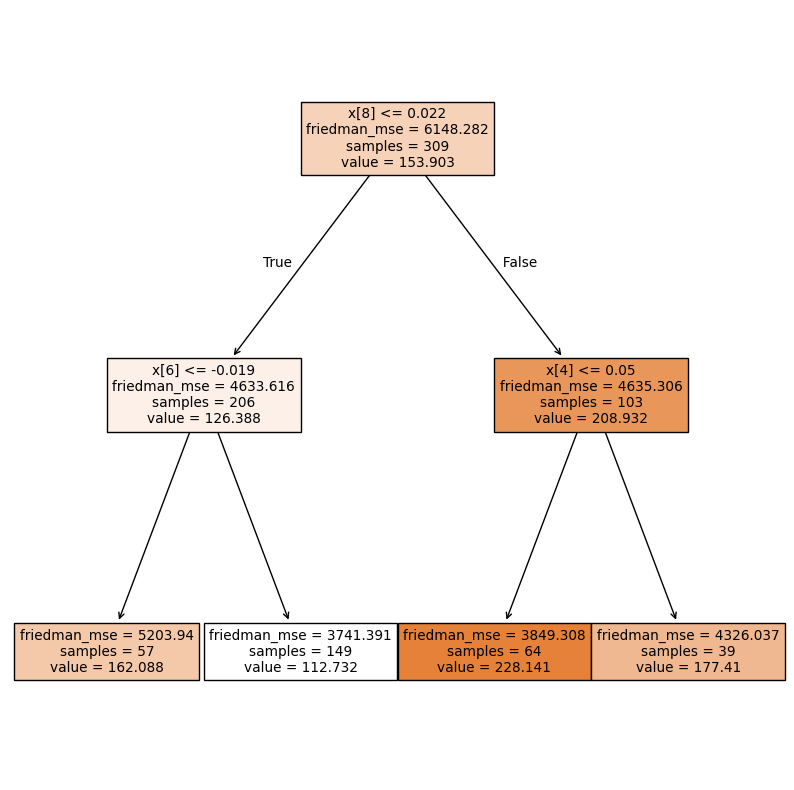

In [31]:
#visualize tree
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(grid.best_estimator_,filled=True)
plt.show()